# CLasificacion de imagenes de escarabajos con CNN

Dataset usado: https://www.kaggle.com/datasets/kmldas/insect-identification-from-habitus-images

In [1]:
import torch 
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
device

'cuda'

In [9]:
# Renombrar carpetas 
import os
import pandas as pd

PATH = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database'

# Obtener solo carpetas
carpetas = [
    nombre for nombre in os.listdir(PATH)
    if os.path.isdir(os.path.join(PATH, nombre))
]

# Ordenarlas para que el renombrado sea reproducible
carpetas = sorted(carpetas)

mapeo = []

# Primero renombrar a nombres temporales para evitar conflictos
for i, nombre_original in enumerate(carpetas, start=1):
    ruta_original = os.path.join(PATH, nombre_original)
    ruta_temporal = os.path.join(PATH, f'__temp_clase_{i}')

    os.rename(ruta_original, ruta_temporal)

    mapeo.append({
        'nombre_original': nombre_original,
        'nombre_temporal': f'__temp_clase_{i}',
        'nombre_nuevo': f'Clase_{i}'
    })

# Luego renombrar de temporal a Clase_1, Clase_2, ...
for item in mapeo:
    ruta_temporal = os.path.join(PATH, item['nombre_temporal'])
    ruta_nueva = os.path.join(PATH, item['nombre_nuevo'])

    os.rename(ruta_temporal, ruta_nueva)

# Guardar equivalencias
df_mapeo = pd.DataFrame(mapeo)
df_mapeo = df_mapeo[['nombre_original', 'nombre_nuevo']]

df_mapeo.to_csv(
    os.path.join(PATH, 'mapeo_clases.csv'),
    index=False,
    encoding='utf-8'
)

print("Carpetas renombradas correctamente.")
print(df_mapeo)

Carpetas renombradas correctamente.
    nombre_original nombre_nuevo
0           1035167      Clase_1
1           1035185      Clase_2
2           1035194      Clase_3
3           1035195      Clase_4
4           1035204      Clase_5
..              ...          ...
286         9444427    Clase_287
287         9479706    Clase_288
288         9491931    Clase_289
289         9533851    Clase_290
290         9581584    Clase_291

[291 rows x 2 columns]


In [2]:

PATH = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database'

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.ImageFolder(
    root=PATH,
    transform=transform
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

dataloader = {
    'train': torch.utils.data.DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        pin_memory=False
    ),
    'test': torch.utils.data.DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        pin_memory=False
    )
}

RESUMEN DEL BALANCE DE CLASES - TRAIN
Total de clases: 291
Total de imágenes: 50691
Clase con más imágenes: Clase_283 (704)
Clase con menos imágenes: Clase_81 (39)
Promedio de imágenes por clase: 174.20
Mediana de imágenes por clase: 140.00


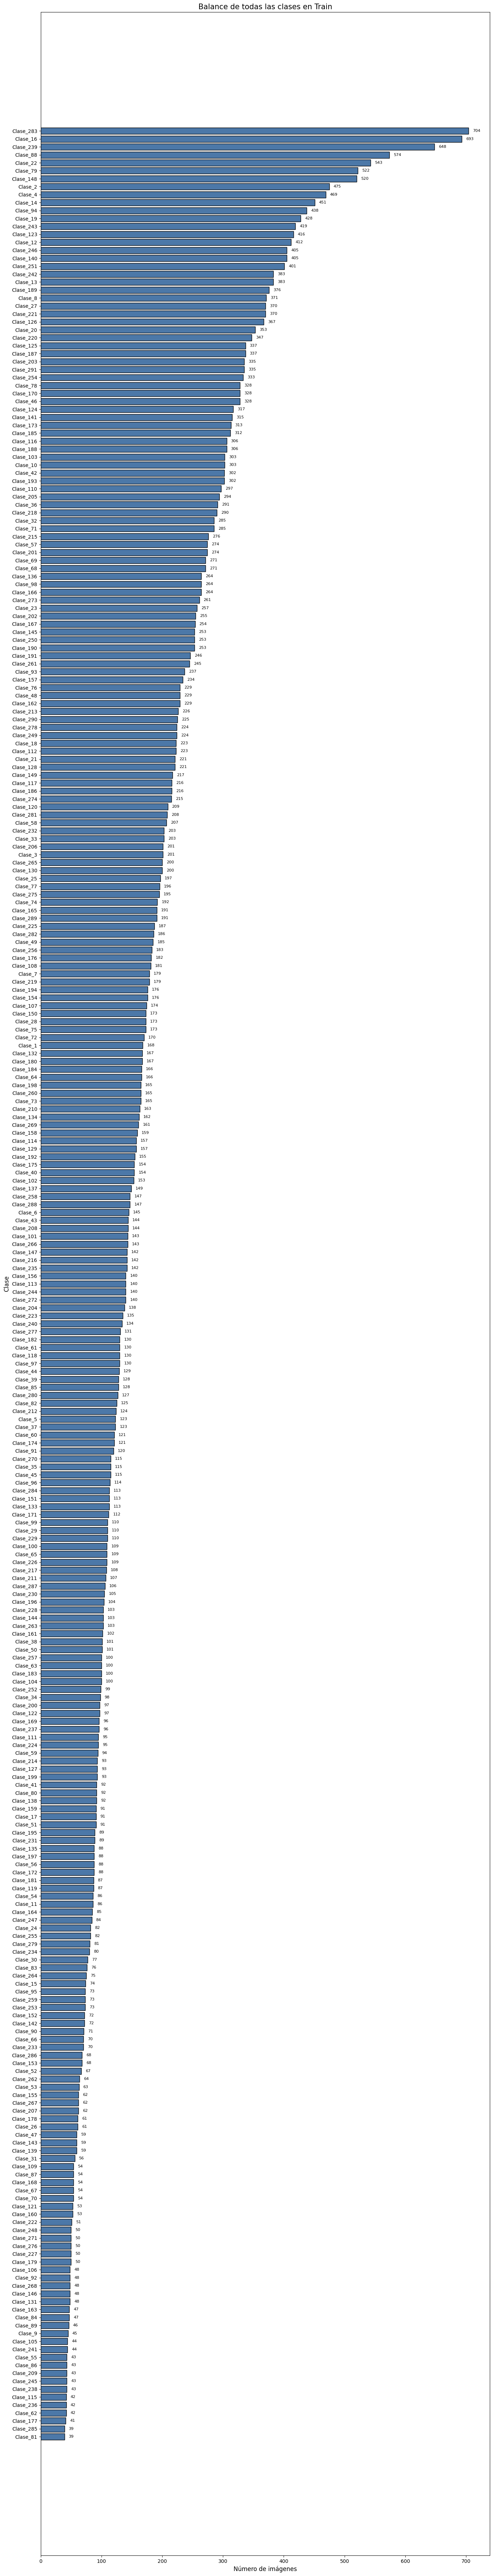

In [13]:
# Visualizar balance de todas las clases

import matplotlib.pyplot as plt
import pandas as pd

# Obtener subset de entrenamiento
train_subset = dataloader['train'].dataset

# Dataset original ImageFolder
dataset_original = train_subset.dataset

# Nombres de clases
nombres_clases = dataset_original.classes

# Etiquetas solo del conjunto train
etiquetas_train = [dataset_original.targets[i] for i in train_subset.indices]

# Contar imágenes por clase
conteo_clases = []
for i, nombre in enumerate(nombres_clases):
    conteo = sum(1 for etiqueta in etiquetas_train if etiqueta == i)
    conteo_clases.append(conteo)

# Crear DataFrame ordenado
df_balance = pd.DataFrame({
    'Clase': nombres_clases,
    'Cantidad': conteo_clases
}).sort_values('Cantidad', ascending=False)

# Mostrar resumen numérico
print("="*50)
print("RESUMEN DEL BALANCE DE CLASES - TRAIN")
print("="*50)
print(f"Total de clases: {len(df_balance)}")
print(f"Total de imágenes: {df_balance['Cantidad'].sum()}")
print(f"Clase con más imágenes: {df_balance.iloc[0]['Clase']} ({df_balance.iloc[0]['Cantidad']})")
print(f"Clase con menos imágenes: {df_balance.iloc[-1]['Clase']} ({df_balance.iloc[-1]['Cantidad']})")
print(f"Promedio de imágenes por clase: {df_balance['Cantidad'].mean():.2f}")
print(f"Mediana de imágenes por clase: {df_balance['Cantidad'].median():.2f}")
print("="*50)

# Ajustar altura automáticamente según la cantidad de clases
alto_figura = max(10, len(df_balance) * 0.25)

plt.figure(figsize=(14, alto_figura))

bars = plt.barh(
    df_balance['Clase'],
    df_balance['Cantidad'],
    color='#4C78A8',
    edgecolor='black'
)

plt.gca().invert_yaxis()

plt.title('Balance de todas las clases en Train', fontsize=15)
plt.xlabel('Número de imágenes', fontsize=12)
plt.ylabel('Clase', fontsize=12)

# Agregar valores al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(df_balance['Cantidad']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

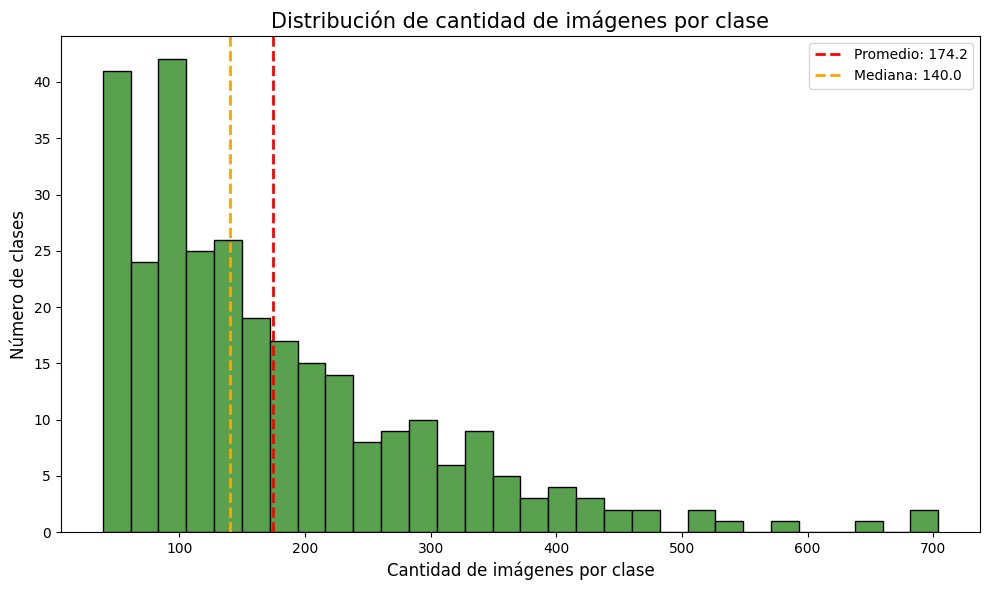

In [12]:
# Distribución general: cuántas clases tienen pocas o muchas imágenes

plt.figure(figsize=(10, 6))

plt.hist(
    df_balance['Cantidad'],
    bins=30,
    color='#59A14F',
    edgecolor='black'
)

plt.title('Distribución de cantidad de imágenes por clase', fontsize=15)
plt.xlabel('Cantidad de imágenes por clase', fontsize=12)
plt.ylabel('Número de clases', fontsize=12)

plt.axvline(
    df_balance['Cantidad'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Promedio: {df_balance['Cantidad'].mean():.1f}"
)

plt.axvline(
    df_balance['Cantidad'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Mediana: {df_balance['Cantidad'].median():.1f}"
)

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import os
import shutil
import random
from PIL import Image

import torch
import torchvision
from torchvision import transforms

# Ruta del dataset original
PATH = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database'

# Ruta donde se guardará el train balanceado
PATH_TRAIN_BALANCEADO = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database_train_balanceado_174'

# Cantidad objetivo por clase
OBJETIVO_POR_CLASE = 174

# Tomar el subset de entrenamiento ya creado
train_subset = dataloader['train'].dataset
dataset_original = train_subset.dataset

clases = dataset_original.classes
samples = dataset_original.samples

# Crear carpeta destino desde cero
if os.path.exists(PATH_TRAIN_BALANCEADO):
    shutil.rmtree(PATH_TRAIN_BALANCEADO)

os.makedirs(PATH_TRAIN_BALANCEADO, exist_ok=True)

# Transformaciones aleatorias para oversampling
augmentacion = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.8, 1.0)
    )
])

# Agrupar imágenes del train por clase
imagenes_por_clase = {i: [] for i in range(len(clases))}

for idx in train_subset.indices:
    ruta_imagen, etiqueta = samples[idx]
    imagenes_por_clase[etiqueta].append(ruta_imagen)

print("="*60)
print("BALANCEO DEL CONJUNTO DE ENTRENAMIENTO")
print("="*60)

# Balancear cada clase hacia 174 imágenes
for clase_idx, rutas in imagenes_por_clase.items():
    nombre_clase = clases[clase_idx]
    carpeta_destino = os.path.join(PATH_TRAIN_BALANCEADO, nombre_clase)
    os.makedirs(carpeta_destino, exist_ok=True)

    cantidad_actual = len(rutas)

    # Caso 1: clase con demasiadas imágenes -> undersampling
    if cantidad_actual > OBJETIVO_POR_CLASE:
        rutas_seleccionadas = random.sample(rutas, OBJETIVO_POR_CLASE)
        accion = "undersampling"

    # Caso 2: clase con 174 o menos -> conservar todas
    else:
        rutas_seleccionadas = rutas
        accion = "oversampling" if cantidad_actual < OBJETIVO_POR_CLASE else "sin cambios"

    # Copiar imágenes originales seleccionadas
    for i, ruta in enumerate(rutas_seleccionadas):
        extension = os.path.splitext(ruta)[1]
        nueva_ruta = os.path.join(carpeta_destino, f"original_{i}{extension}")
        shutil.copy2(ruta, nueva_ruta)

    # Si faltan imágenes, generar aumentadas
    faltantes = OBJETIVO_POR_CLASE - len(rutas_seleccionadas)

    for j in range(faltantes):
        ruta_base = random.choice(rutas)

        imagen = Image.open(ruta_base).convert("RGB")
        imagen_aug = augmentacion(imagen)

        ruta_salida = os.path.join(
            carpeta_destino,
            f"aug_{j}.jpg"
        )

        imagen_aug.save(ruta_salida, quality=95)

    print(
        f"{nombre_clase}: {cantidad_actual} -> {OBJETIVO_POR_CLASE} "
        f"({accion}, generadas {faltantes})"
    )

print("="*60)
print("Balanceo terminado.")
print("Dataset balanceado guardado en:")
print(PATH_TRAIN_BALANCEADO)

BALANCEO DEL CONJUNTO DE ENTRENAMIENTO
Clase_1: 168 -> 174 (oversampling, generadas 6)
Clase_10: 303 -> 174 (undersampling, generadas 0)
Clase_100: 109 -> 174 (oversampling, generadas 65)
Clase_101: 143 -> 174 (oversampling, generadas 31)
Clase_102: 153 -> 174 (oversampling, generadas 21)
Clase_103: 303 -> 174 (undersampling, generadas 0)
Clase_104: 100 -> 174 (oversampling, generadas 74)
Clase_105: 44 -> 174 (oversampling, generadas 130)
Clase_106: 48 -> 174 (oversampling, generadas 126)
Clase_107: 174 -> 174 (sin cambios, generadas 0)
Clase_108: 181 -> 174 (undersampling, generadas 0)
Clase_109: 54 -> 174 (oversampling, generadas 120)
Clase_11: 86 -> 174 (oversampling, generadas 88)
Clase_110: 297 -> 174 (undersampling, generadas 0)
Clase_111: 95 -> 174 (oversampling, generadas 79)
Clase_112: 223 -> 174 (undersampling, generadas 0)
Clase_113: 140 -> 174 (oversampling, generadas 34)
Clase_114: 157 -> 174 (oversampling, generadas 17)
Clase_115: 42 -> 174 (oversampling, generadas 132)
C

In [16]:
dataset.classes

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 50691
Test: 12673


In [7]:
import torch
import torchvision
from torchvision import transforms

# Ruta del dataset original
PATH = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database'

# Ruta donde se guardará el train balanceado
PATH_TRAIN_BALANCEADO = 'C:/Users/aaran/Downloads/Insect identification from habitus images/database_train_balanceado_174'

# Cantidad objetivo por clase
OBJETIVO_POR_CLASE = 174

# Tomar el subset de entrenamiento ya creado
train_subset = dataloader['train'].dataset
dataset_original = train_subset.dataset

clases = dataset_original.classes
samples = dataset_original.samples

# Transformaciones para transfer learning con modelos preentrenados en ImageNet
# RegNetY-16GF fue preentrenado con esta normalizacion.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset_balanceado = torchvision.datasets.ImageFolder(
    root=PATH_TRAIN_BALANCEADO,
    transform=transform_train
)

test_subset = dataloader['test'].dataset
test_subset.dataset.transform = transform_test

dataloader = {
    'train': torch.utils.data.DataLoader(
        train_dataset_balanceado,
        batch_size=16,
        shuffle=True,
        pin_memory=torch.cuda.is_available()
    ),
    'test': torch.utils.data.DataLoader(
        test_subset,
        batch_size=32,
        shuffle=False,
        pin_memory=torch.cuda.is_available()
    )
}

NUM_CLASSES = len(train_dataset_balanceado.classes)

print("Train balanceado:", len(dataloader['train'].dataset))
print("Test original:", len(dataloader['test'].dataset))
print("Clases:", NUM_CLASSES)


Train balanceado: 50634
Test original: 12673
Clases: 291


RESUMEN DEL NUEVO BALANCE - TRAIN
Total de clases: 291
Total de imágenes: 50634
Clase con más imágenes: Clase_1 (174)
Clase con menos imágenes: Clase_99 (174)
Promedio de imágenes por clase: 174.00
Mediana de imágenes por clase: 174.00


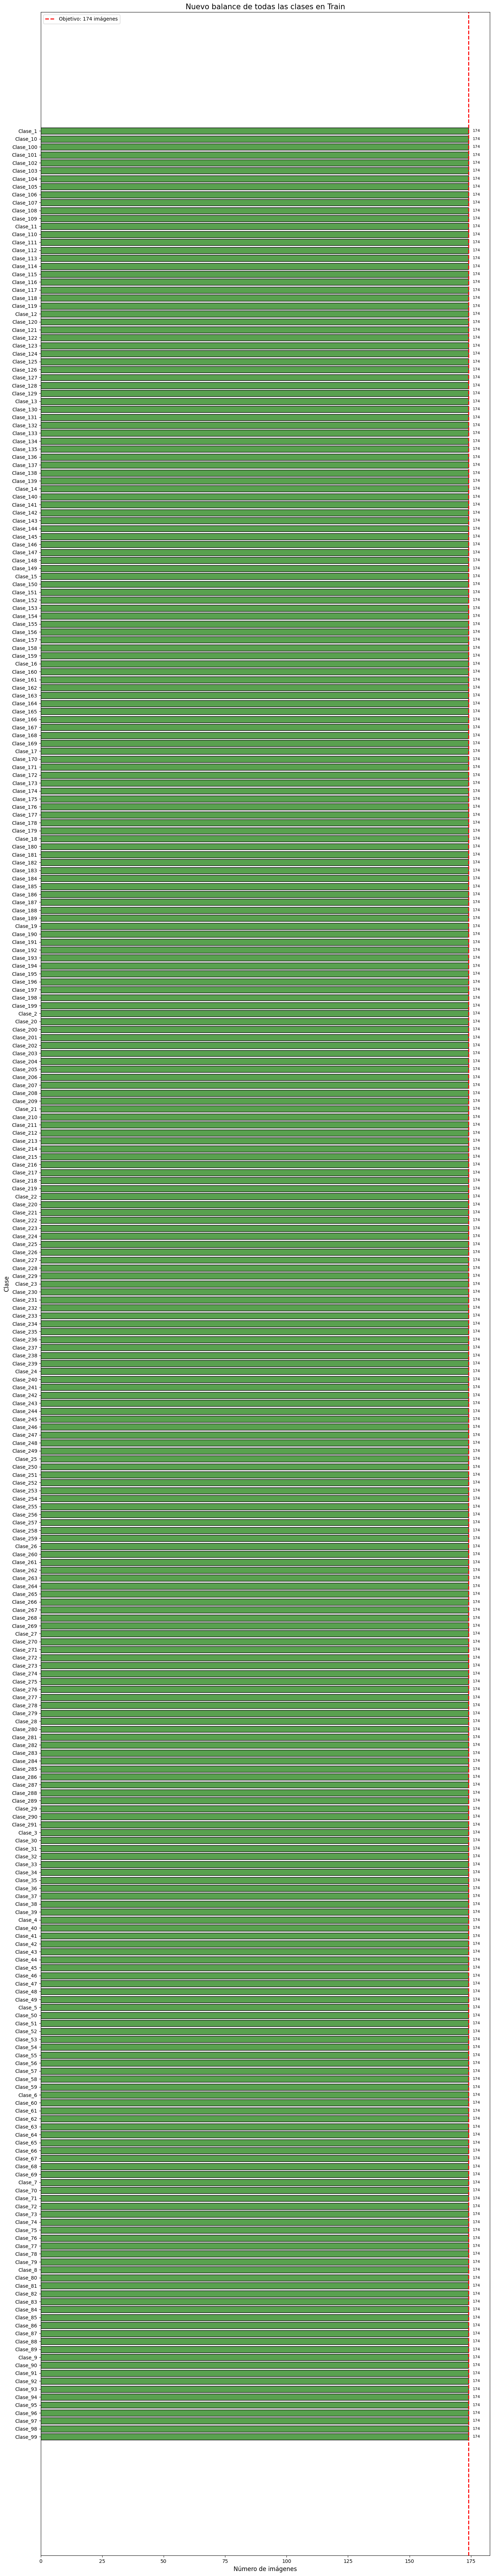

In [8]:
# Visualizar nuevo balance después de undersampling + oversampling

import matplotlib.pyplot as plt
import pandas as pd

# Dataset balanceado
train_dataset_balanceado = dataloader['train'].dataset

# Nombres de clases
nombres_clases = train_dataset_balanceado.classes

# Etiquetas del dataset balanceado
etiquetas = train_dataset_balanceado.targets

# Contar imágenes por clase
conteo_clases = []
for i in range(len(nombres_clases)):
    conteo = sum(1 for etiqueta in etiquetas if etiqueta == i)
    conteo_clases.append(conteo)

# Crear DataFrame
df_balance_nuevo = pd.DataFrame({
    'Clase': nombres_clases,
    'Cantidad': conteo_clases
}).sort_values('Cantidad', ascending=False)

# Resumen numérico
print("="*50)
print("RESUMEN DEL NUEVO BALANCE - TRAIN")
print("="*50)
print(f"Total de clases: {len(df_balance_nuevo)}")
print(f"Total de imágenes: {df_balance_nuevo['Cantidad'].sum()}")
print(f"Clase con más imágenes: {df_balance_nuevo.iloc[0]['Clase']} ({df_balance_nuevo.iloc[0]['Cantidad']})")
print(f"Clase con menos imágenes: {df_balance_nuevo.iloc[-1]['Clase']} ({df_balance_nuevo.iloc[-1]['Cantidad']})")
print(f"Promedio de imágenes por clase: {df_balance_nuevo['Cantidad'].mean():.2f}")
print(f"Mediana de imágenes por clase: {df_balance_nuevo['Cantidad'].median():.2f}")
print("="*50)

# Altura automática
alto_figura = max(10, len(df_balance_nuevo) * 0.25)

plt.figure(figsize=(14, alto_figura))

bars = plt.barh(
    df_balance_nuevo['Clase'],
    df_balance_nuevo['Cantidad'],
    color='#59A14F',
    edgecolor='black'
)

plt.gca().invert_yaxis()

plt.title('Nuevo balance de todas las clases en Train', fontsize=15)
plt.xlabel('Número de imágenes', fontsize=12)
plt.ylabel('Clase', fontsize=12)

# Línea objetivo
plt.axvline(
    x=174,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Objetivo: 174 imágenes'
)

# Agregar valores en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(df_balance_nuevo['Cantidad']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=8
    )

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Para entrenamientos de prueba con pocas imágenes

import torch
from torch.utils.data import random_split

# 1. Tomar el dataset de entrenamiento actual
# Puede ser el train balanceado o el train original, según lo que tengas en dataloader['train']
full_train_dataset = dataloader['train'].dataset

# 2. Definir cuántas imágenes usar para la prueba
num_muestras_prueba = 2000

# Evitar error si pides más imágenes de las que existen
num_muestras_prueba = min(num_muestras_prueba, len(full_train_dataset))

# 3. Dividir: subset pequeño + resto
subset_train_dataset, _ = random_split(
    full_train_dataset,
    [
        num_muestras_prueba,
        len(full_train_dataset) - num_muestras_prueba
    ],
    generator=torch.Generator().manual_seed(42)
)

# 4. Crear dataloader limitado
dataloader_limitado = {
    'train': torch.utils.data.DataLoader(
        subset_train_dataset,
        batch_size=32,
        shuffle=True,
        pin_memory=False
    ),
    'test': dataloader['test']
}

print("Train completo:", len(full_train_dataset))
print("Train limitado:", len(dataloader_limitado['train'].dataset))
print("Test:", len(dataloader_limitado['test'].dataset))

Train completo: 50634
Train limitado: 2000
Test: 12673


In [9]:
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(pk, stride=ps)
    )

In [10]:
class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=291, input_size=224): # ¡OJO! Pon 291 aquí
    super().__init__()
    self.conv1 = block(n_channels, 32)
    self.conv2 = block(32, 64)
    self.conv3 = block(64, 128)  # ¡La capa nueva!
    self.conv4 = block(128, 256)

    # 1. Tensor falso
    dummy_input = torch.zeros(1, n_channels, input_size, input_size)
    
    # 2. ¡Pásalo POR LAS 3 CAPAS!
    dummy_output = self.conv3(self.conv2(self.conv1(dummy_input)))
    
    # 3. Calcula el nuevo número de features
    # Conv1: 224->112, Conv2: 112->56, Conv3: 56->28
    # Features = 128 (canales) * 28 * 28 = 100,352
    num_features = dummy_output.view(1, -1).shape[1]
    
    self.fc = torch.nn.Linear(num_features, n_outputs)
    self.dropout = torch.nn.Dropout(p=0.3)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)  # <--- ¡LÍNEA AGREGADA AQUÍ!
    x = self.conv4(x)
    x = x.view(x.shape[0], -1)
    x = self.dropout(x)
    x = self.fc(x)
    return x

In [11]:
import torch
import torch.nn as nn

def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.ReLU(),
        nn.MaxPool2d(pk, stride=ps)
    )

class CNN5Layers_GAP(nn.Module):
    def __init__(self, n_channels=3, n_outputs=291, input_size=224):
        super().__init__()
        
        # ==========================================
        # 1. CUERPO CONVOLUCIONAL (5 bloques)
        # ==========================================
        # Progresión de filtros: 64 -> 128 -> 256 -> 512 -> 512
        self.conv1 = block(n_channels, 64)   # 224x224 -> 112x112
        self.conv2 = block(64, 128)          # 112x112 -> 56x56
        self.conv3 = block(128, 256)         # 56x56 -> 28x28
        self.conv4 = block(256, 512)         # 28x28 -> 14x14
        self.conv5 = block(512, 512)         # 14x14 -> 7x7  (¡Aquí paramos!)
        
        # ==========================================
        # 2. CABEZA CLASIFICADORA (GAP + FC)
        # ==========================================
        # GAP convierte 7x7x512 en 1x1x512 (reduce 25,088 features a solo 512)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Dropout fuerte (50%) porque tienes muchas clases y datos limitados
        self.dropout = nn.Dropout(p=0.5)
        
        # Capa final: 512 -> 291 clases
        # ¡Solo 512 * 291 = 149,000 parámetros! (vs millones con Flatten)
        self.fc = nn.Linear(512, n_outputs)

    def forward(self, x):
        # Cuerpo convolucional
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)              # [Batch, 512, 7, 7]
        
        # Cabeza
        x = self.gap(x)                # [Batch, 512, 1, 1]
        x = x.view(x.size(0), -1)      # [Batch, 512]
        x = self.dropout(x)
        x = self.fc(x)                 # [Batch, 291]
        return x

In [12]:
from tqdm import tqdm
import numpy as np
import copy
import torch

def fit(
    model,
    dataloader,
    epochs=1,
    patience=8,
    min_delta=0.001,
    lr=1e-3,
    scheduler_patience=3,
    scheduler_factor=0.5,
    min_lr=1e-6
):
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr
    )

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_sin_mejora = 0

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss, train_acc = [], []

        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()

            y_hat = model(X)
            loss = criterion(y_hat, y)

            loss.backward()
            optimizer.step()

            train_loss.append(loss.item())

            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)

            bar.set_description(
                f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}"
            )

        model.eval()

        val_loss, val_acc = [], []

        with torch.no_grad():
            bar = tqdm(dataloader['test'])
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)

                y_hat = model(X)
                loss = criterion(y_hat, y)

                val_loss.append(loss.item())

                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)

                bar.set_description(
                    f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}"
                )

        epoch_train_loss = np.mean(train_loss)
        epoch_train_acc = np.mean(train_acc)
        epoch_val_loss = np.mean(val_loss)
        epoch_val_acc = np.mean(val_acc)

        # Scheduler: baja el learning rate si val_loss se estanca
        scheduler.step(epoch_val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['lr'].append(current_lr)

        print(
            f"Epoch {epoch}/{epochs} "
            f"loss {epoch_train_loss:.5f} "
            f"val_loss {epoch_val_loss:.5f} "
            f"acc {epoch_train_acc:.5f} "
            f"val_acc {epoch_val_acc:.5f} "
            f"lr {current_lr:.8f}"
        )

        # Early stopping
        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_sin_mejora = 0

            print(f"Mejor val_loss encontrado: {best_val_loss:.5f}")
        else:
            epochs_sin_mejora += 1

            print(f"Sin mejora: {epochs_sin_mejora}/{patience}")

            if epochs_sin_mejora >= patience:
                print("Early stopping activado.")
                break

    model.load_state_dict(best_model_weights)

    return model, history

In [13]:
model = CNN5Layers_GAP(n_outputs=291)
fit(model, dataloader, epochs=3) 

val_loss 5.67381 val_acc 0.00559: 100%|██████████| 397/397 [02:20<00:00,  2.83it/s]


Epoch 1/3 loss 5.67573 val_loss 5.67381 acc 0.00269 val_acc 0.00559 lr 0.00100000
Mejor val_loss encontrado: 5.67381


val_loss 5.67305 val_acc 0.00559: 100%|██████████| 397/397 [01:31<00:00,  4.34it/s]


Epoch 2/3 loss 5.67527 val_loss 5.67305 acc 0.00263 val_acc 0.00559 lr 0.00100000
Sin mejora: 1/8


val_loss 5.67263 val_acc 0.00157: 100%|██████████| 397/397 [01:16<00:00,  5.17it/s]

Epoch 3/3 loss 5.67524 val_loss 5.67263 acc 0.00274 val_acc 0.00157 lr 0.00100000
Mejor val_loss encontrado: 5.67263


(CNN5Layers_GAP(
   (conv1): Sequential(
     (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv2): Sequential(
     (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv3): Sequential(
     (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv4): Sequential(
     (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv5): Sequential(
     (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=

🔍 Evaluando el modelo para generar la matriz de confusión...


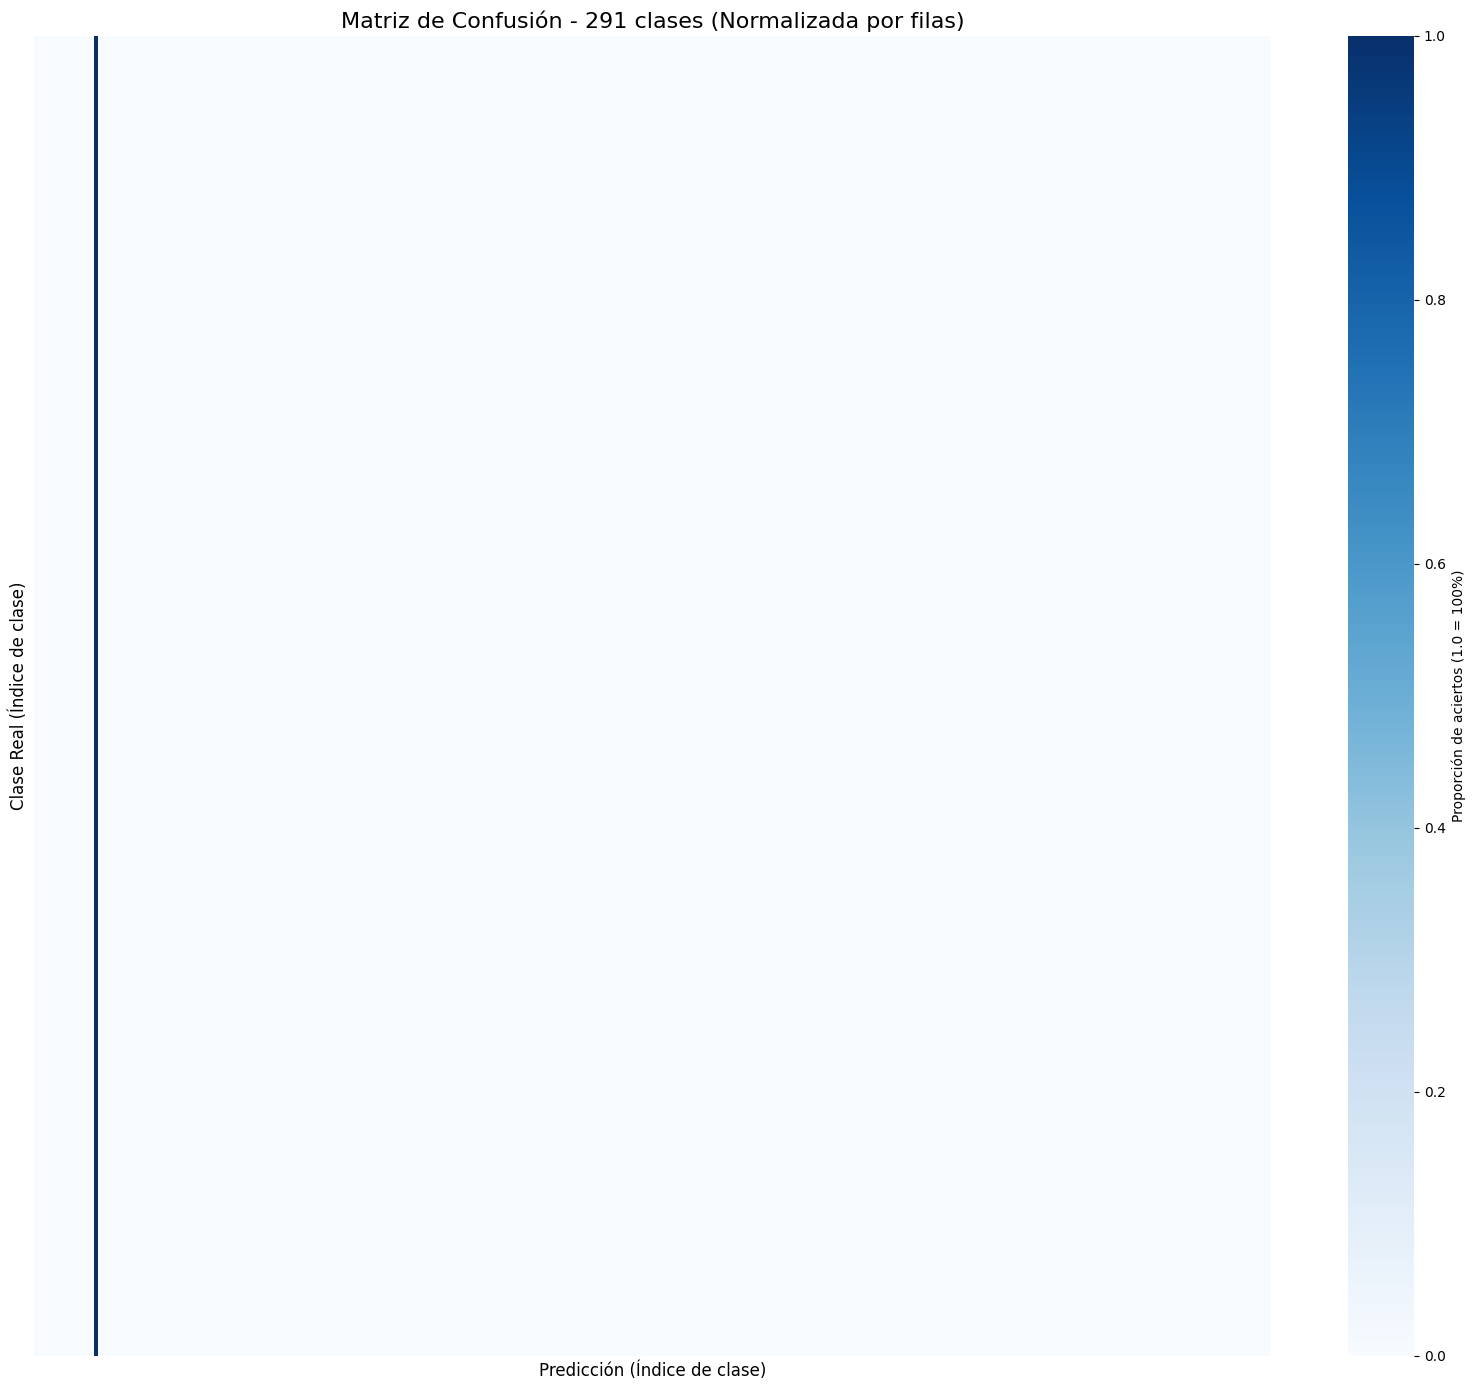


📊 ESTADÍSTICAS DE LA MATRIZ DE CONFUSIÓN
✅ Promedio de aciertos por clase (Recall promedio): 0.0034
🔴 Clases con 0% de aciertos: 290 / 291
🟠 Clases con menos del 10% de aciertos: 0 / 291

🔽 TOP 10 CLASES CON PEOR RENDIMIENTO (Recall más bajo):
   Clase 289: 0.00% de aciertos
   Clase 273: 0.00% de aciertos
   Clase 274: 0.00% de aciertos
   Clase 275: 0.00% de aciertos
   Clase 276: 0.00% de aciertos
   Clase 277: 0.00% de aciertos
   Clase 278: 0.00% de aciertos
   Clase 279: 0.00% de aciertos
   Clase 280: 0.00% de aciertos
   Clase 281: 0.00% de aciertos


In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataloader, device, num_classes=291, figsize=(16, 14)):
    """
    Evalúa el modelo y dibuja la matriz de confusión normalizada.
    """
    model.eval()
    
    todas_preds = []
    todas_labels = []
    
    print("🔍 Evaluando el modelo para generar la matriz de confusión...")
    
    with torch.no_grad():
        for imagenes, etiquetas in dataloader:
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            
            salidas = model(imagenes)
            _, preds = torch.max(salidas, 1)
            
            todas_preds.extend(preds.cpu().numpy())
            todas_labels.extend(etiquetas.cpu().numpy())
    
    y_pred = np.array(todas_preds)
    y_true = np.array(todas_labels)
    
    # --- Calcular la matriz de confusión ---
    cm = confusion_matrix(y_true, y_pred)
    
    # --- Normalizar por filas (clase real) para ver proporción de aciertos ---
    # Cada fila suma 1.0 (el 100% de las imágenes de esa clase)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)  # Rellenar NaN (clases sin ejemplos) con 0
    
    # --- Visualización ---
    plt.figure(figsize=figsize)
    
    # 'annot=False' porque con 291 clases, escribir números dentro es ilegible.
    # Si quieres ver los números, cámbialo a 'annot=True' pero solo funcionará bien si figsize es enorme (ej: 40x40).
    sns.heatmap(
        cm_norm, 
        annot=False,          # No muestra números dentro (para no saturar)
        fmt='.2f', 
        cmap='Blues',         # Mapa de colores: blanco (0%) a azul oscuro (100%)
        xticklabels=False,    # Oculta las etiquetas del eje X (son 291, no caben)
        yticklabels=False,    # Oculta las etiquetas del eje Y
        cbar_kws={'label': 'Proporción de aciertos (1.0 = 100%)'}
    )
    
    plt.title(f'Matriz de Confusión - {num_classes} clases (Normalizada por filas)', fontsize=16)
    plt.xlabel('Predicción (Índice de clase)', fontsize=12)
    plt.ylabel('Clase Real (Índice de clase)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- Estadísticas rápidas (solo texto) ---
    aciertos_por_clase = np.diag(cm_norm)  # Diagonal principal: % de acierto de cada clase
    promedio_general = np.mean(aciertos_por_clase)
    
    clases_con_cero = np.sum(aciertos_por_clase == 0)
    clases_con_menos_del_10 = np.sum((aciertos_por_clase > 0) & (aciertos_por_clase < 0.1))
    
    print("\n" + "="*50)
    print("📊 ESTADÍSTICAS DE LA MATRIZ DE CONFUSIÓN")
    print("="*50)
    print(f"✅ Promedio de aciertos por clase (Recall promedio): {promedio_general:.4f}")
    print(f"🔴 Clases con 0% de aciertos: {clases_con_cero} / {num_classes}")
    print(f"🟠 Clases con menos del 10% de aciertos: {clases_con_menos_del_10} / {num_classes}")
    
    # Opcional: Mostrar las 5 clases con peor rendimiento
    peores_indices = np.argsort(aciertos_por_clase)[:10]
    print("\n🔽 TOP 10 CLASES CON PEOR RENDIMIENTO (Recall más bajo):")
    for idx in peores_indices:
        print(f"   Clase {idx}: {aciertos_por_clase[idx]:.2%} de aciertos")
    print("="*50)
    
    return cm  # Devuelve la matriz sin normalizar por si quieres guardarla

# ============================================================
# 🚀 EJECUCIÓN (Pega esto justo después de tu 'fit')
# ============================================================

# Suponiendo que tienes:
# - model: tu modelo ya entrenado (con los mejores pesos cargados)
# - dataloader: tu diccionario con 'test' (o 'val')
# - device: 'cuda' o 'cpu'

# Llama a la función con tu dataloader de TEST
matriz_resultante = plot_confusion_matrix(
    model=model,                     # Tu modelo
    dataloader=dataloader['test'],   # Tu conjunto de prueba
    device=device,                   # 'cuda' o 'cpu'
    num_classes=291,                 # Número total de clases
    figsize=(16, 14)                 # Tamaño del gráfico
)

# Si quieres guardar la matriz en un archivo .npy para usarla después:
# np.save('matriz_confusion.npy', matriz_resultante)

## Transfer Learning con RegNetY-16GF

Usamos una red preentrenada, reemplazamos su capa final por una nueva cabeza clasificadora para las clases de escarabajos y podemos congelar/descongelar el extractor de caracteristicas.

In [14]:
import torch.nn as nn
from torchvision.models import RegNet_Y_16GF_Weights, regnet_y_16gf

class RegNetY16GFTransfer(nn.Module):
    def __init__(self, n_outputs=NUM_CLASSES, pretrained=True, freeze=True, dropout=0.4):
        super().__init__()
        weights = RegNet_Y_16GF_Weights.DEFAULT if pretrained else None
        self.regnet = regnet_y_16gf(weights=weights)

        in_features = self.regnet.fc.in_features
        self.regnet.fc = nn.Identity()

        if freeze:
            self.freeze()

        self.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, n_outputs)
        )

    def forward(self, x):
        x = self.regnet(x)
        x = self.fc(x)
        return x

    def freeze(self):
        for param in self.regnet.parameters():
            param.requires_grad = False

    def unfreeze(self):
        for param in self.regnet.parameters():
            param.requires_grad = True


In [15]:
# Prueba rapida de dimensiones: batch x NUM_CLASSES
model_regnet = RegNetY16GFTransfer(n_outputs=NUM_CLASSES, pretrained=True, freeze=True)
outputs = model_regnet(torch.randn(2, 3, 224, 224))
print(outputs.shape)


Downloading: "https://download.pytorch.org/models/regnet_y_16gf-3e4a00f9.pth" to C:\Users\aaran/.cache\torch\hub\checkpoints\regnet_y_16gf-3e4a00f9.pth


100%|██████████| 319M/319M [00:24<00:00, 13.8MB/s] 


torch.Size([2, 291])


In [16]:
from tqdm import tqdm
import numpy as np
import copy

def fit_transfer(
    model,
    dataloader,
    epochs=5,
    lr_backbone=1e-5,
    lr_fc=1e-3,
    patience=5,
    min_delta=0.001,
    scheduler_patience=2,
    scheduler_factor=0.5,
    min_lr=1e-7
):
    model.to(device)

    optimizer = torch.optim.Adam([
        {'params': model.regnet.parameters(), 'lr': lr_backbone},
        {'params': model.fc.parameters(), 'lr': lr_fc}
    ])
    criterion = nn.CrossEntropyLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr
    )

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_sin_mejora = 0

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr_backbone': [],
        'lr_fc': []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_acc = [], []

        bar = tqdm(dataloader['train'])
        for X, y in bar:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()

            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, dim=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")

        model.eval()
        val_loss, val_acc = [], []

        with torch.no_grad():
            bar = tqdm(dataloader['test'])
            for X, y in bar:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)

                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, dim=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")

        epoch_train_loss = np.mean(train_loss)
        epoch_train_acc = np.mean(train_acc)
        epoch_val_loss = np.mean(val_loss)
        epoch_val_acc = np.mean(val_acc)

        scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['lr_backbone'].append(optimizer.param_groups[0]['lr'])
        history['lr_fc'].append(optimizer.param_groups[1]['lr'])

        print(
            f"Epoch {epoch}/{epochs} "
            f"loss {epoch_train_loss:.5f} val_loss {epoch_val_loss:.5f} "
            f"acc {epoch_train_acc:.5f} val_acc {epoch_val_acc:.5f} "
            f"lr_backbone {optimizer.param_groups[0]['lr']:.8f} "
            f"lr_fc {optimizer.param_groups[1]['lr']:.8f}"
        )

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_sin_mejora = 0
            print(f"Mejor val_loss encontrado: {best_val_loss:.5f}")
        else:
            epochs_sin_mejora += 1
            print(f"Sin mejora: {epochs_sin_mejora}/{patience}")

            if epochs_sin_mejora >= patience:
                print("Early stopping activado.")
                break

    model.load_state_dict(best_model_weights)
    return model, history


In [ ]:
# Fase 1: transfer learning con el extractor congelado.
# Esta fase entrena solo la nueva cabeza clasificadora.
model_regnet = RegNetY16GFTransfer(n_outputs=NUM_CLASSES, pretrained=True, freeze=True)
model_regnet, history_frozen = fit_transfer(
    model_regnet,
    dataloader,
    epochs=3,
    lr_backbone=0.0,
    lr_fc=1e-3
)


loss 3.95354 acc 0.18733:  36%|███▌      | 1131/3165 [13:07<1:37:53,  2.89s/it]

In [ ]:
# Fase 2: fine tuning. Descongelamos RegNetY-16GF y usamos un lr menor en el backbone.
model_regnet.unfreeze()
model_regnet, history_finetuning = fit_transfer(
    model_regnet,
    dataloader,
    epochs=3,
    lr_backbone=1e-5,
    lr_fc=1e-4
)
